# RNN from scratch: manually unrolling a SimpleRNN cell

Companion to `notes.md`'s "From-scratch implementation" section. We implement, in plain
NumPy, exactly the recurrence formula from "Mathematical foundation":

$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$

applied to a short toy sequence, one timestep at a time, by hand — using the **same**
weight matrices $W_{xh}, W_{hh}$ at every step (parameter sharing across time). The goal
is to see the hidden state evolve step by step and to confirm it against Keras's
`SimpleRNN` layer running the identical computation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

## A toy sequence

Four "timesteps," each a 3-dimensional input vector — stand-ins for, e.g., four
word-embedding vectors in a short sentence. Small integers are used so every step's
arithmetic can be checked by hand.

In [2]:
X = np.array([
    [1.0, 0.0, 0.0],   # x_1
    [0.0, 1.0, 0.0],   # x_2
    [0.0, 0.0, 1.0],   # x_3
    [1.0, 1.0, 0.0],   # x_4
], dtype=float)
T, n_input = X.shape
n_hidden = 4
print("sequence length T =", T, " input dim =", n_input, " hidden dim =", n_hidden)
print(X)

sequence length T = 4  input dim = 3  hidden dim = 4
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 1. 0.]]


## The recurrent weights — initialized once, reused at every timestep

This is the crux of the architecture per `notes.md`'s "RNN Architecture (vs ANN)"
section: $W_{xh}$, $W_{hh}$, $b_h$ are created **once**, and the exact same three
arrays are used to compute $h_1, h_2, h_3, h_4$ — unlike a plain ANN, which would need
a separate set of weights for each position in a fixed-size flattened input.

In [3]:
Wxh = np.random.randn(n_input, n_hidden) * 0.5
Whh = np.random.randn(n_hidden, n_hidden) * 0.5
bh = np.zeros(n_hidden)

print("Wxh shape:", Wxh.shape)
print("Whh shape:", Whh.shape)
print("bh shape:", bh.shape)

Wxh shape: (3, 4)
Whh shape: (4, 4)
bh shape: (4,)


## Manual unroll: applying $h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$ one step at a time

Starting from $h_0 = \mathbf{0}$, each step below reuses `Wxh`/`Whh`/`bh` and feeds the
previous step's hidden state forward — exactly the forward-propagation description in
`notes.md`'s "Forward & Backward Propagation Through Time" section, written out
explicitly instead of hidden inside a loop, so every intermediate $h_t$ is visible.

In [4]:
h0 = np.zeros(n_hidden)

# Step 1: h_1 = tanh(Wxh @ x_1 + Whh @ h_0 + bh)
z1 = X[0] @ Wxh + h0 @ Whh + bh
h1 = np.tanh(z1)
print("x_1 =", X[0])
print("h_1 =", h1)

x_1 = [1. 0. 0.]
h_1 = [0.7074 0.1975 0.4537 0.8077]


In [5]:
# Step 2: h_2 = tanh(Wxh @ x_2 + Whh @ h_1 + bh)  -- same Wxh, Whh, bh as step 1
z2 = X[1] @ Wxh + h1 @ Whh + bh
h2 = np.tanh(z2)
print("x_2 =", X[1])
print("h_2 =", h2)

x_2 = [0. 1. 0.]
h_2 = [ 0.9339 -0.7187  0.7052 -0.2784]


In [6]:
# Step 3: h_3 = tanh(Wxh @ x_3 + Whh @ h_2 + bh)
z3 = X[2] @ Wxh + h2 @ Whh + bh
h3 = np.tanh(z3)
print("x_3 =", X[2])
print("h_3 =", h3)

x_3 = [0. 0. 1.]
h_3 = [-0.8955  0.6462  0.4343  0.7417]


In [7]:
# Step 4: h_4 = tanh(Wxh @ x_4 + Whh @ h_3 + bh)
z4 = X[3] @ Wxh + h3 @ Whh + bh
h4 = np.tanh(z4)
print("x_4 =", X[3])
print("h_4 =", h4)

x_4 = [1. 1. 0.]
h_4 = [ 0.9778 -0.6678  0.79    0.3703]


## Same computation, written as a loop (for confirmation)

The four steps above are exactly what this loop computes — unrolling it by hand first
makes it clear there is no hidden machinery: each iteration is one application of the
same recurrence formula, applying the same `Wxh`/`Whh`/`bh` reused from the previous
cell.

In [8]:
def simple_rnn_forward(X, Wxh, Whh, bh):
    T = X.shape[0]
    n_hidden = Whh.shape[0]
    h = np.zeros(n_hidden)
    hidden_states = []
    for t in range(T):
        z = X[t] @ Wxh + h @ Whh + bh
        h = np.tanh(z)
        hidden_states.append(h.copy())
    return np.stack(hidden_states)

hidden_states = simple_rnn_forward(X, Wxh, Whh, bh)
print("hidden states h_1..h_4:")
print(hidden_states)

assert np.allclose(hidden_states, np.stack([h1, h2, h3, h4]))
print("\nmatches the hand-unrolled steps above: True")

hidden states h_1..h_4:
[[ 0.7074  0.1975  0.4537  0.8077]
 [ 0.9339 -0.7187  0.7052 -0.2784]
 [-0.8955  0.6462  0.4343  0.7417]
 [ 0.9778 -0.6678  0.79    0.3703]]

matches the hand-unrolled steps above: True


## Watching the hidden state evolve

Each row below is $h_t$ — a fixed-size summary of "everything the cell has seen up to
and including timestep $t$." Plotting each hidden unit's value across timesteps makes
the *evolution* visible: the state at $t=4$ is not a function of $x_4$ alone, it carries
a trace of $x_1, x_2, x_3$ too, mixed in through the repeated $W_{hh}h_{t-1}$ term.

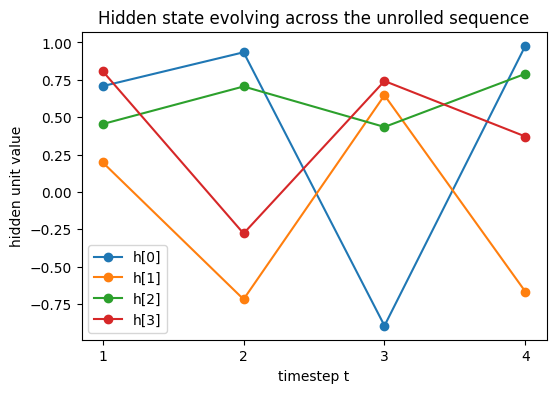

In [9]:
plt.figure(figsize=(6, 4))
for unit in range(n_hidden):
    plt.plot(range(1, T + 1), hidden_states[:, unit], marker="o", label=f"h[{unit}]")
plt.xlabel("timestep t")
plt.ylabel("hidden unit value")
plt.title("Hidden state evolving across the unrolled sequence")
plt.legend()
plt.xticks(range(1, T + 1))
plt.show()

## Proof the early input still influences the final hidden state

Change only $x_1$ (the *first* input, three steps removed from $h_4$) and re-run the
same unroll. If $h_4$ changes, that confirms information really does flow forward
through every intermediate step via $W_{hh}$ — the entire point of "memory" in an RNN,
and the mechanism whose gradient path is exactly what "Failure modes" (vanishing
gradients over many such steps) will show breaking down for *longer* sequences.

In [10]:
X_perturbed = X.copy()
X_perturbed[0] = [5.0, -5.0, 0.0]  # a very different x_1

hidden_states_perturbed = simple_rnn_forward(X_perturbed, Wxh, Whh, bh)

print("h_4 with original x_1:  ", hidden_states[-1])
print("h_4 with perturbed x_1: ", hidden_states_perturbed[-1])
print("\ndifference:", hidden_states_perturbed[-1] - hidden_states[-1])
print("h_4 changed:", not np.allclose(hidden_states[-1], hidden_states_perturbed[-1]))

h_4 with original x_1:   [ 0.9778 -0.6678  0.79    0.3703]
h_4 with perturbed x_1:  [ 0.9855 -0.7097  0.7818  0.3454]

difference: [ 0.0077 -0.0419 -0.0082 -0.025 ]
h_4 changed: True


## Cross-check against `tf.keras.layers.SimpleRNN`

Load the exact same `Wxh`, `Whh`, `bh` into a Keras `SimpleRNN` layer (which internally
runs the same `tanh(W_xh x_t + W_hh h_{t-1} + b_h)` recurrence, just compiled/vectorized
rather than written as an explicit Python loop) and confirm it reproduces the identical
hidden states.

In [11]:
import tensorflow as tf

keras_rnn = tf.keras.layers.SimpleRNN(
    n_hidden, activation="tanh", return_sequences=True, use_bias=True
)
# Build the layer, then overwrite its weights with our exact Wxh, Whh, bh.
keras_rnn.build((None, T, n_input))
keras_rnn.set_weights([Wxh.astype(np.float32), Whh.astype(np.float32), bh.astype(np.float32)])

X_batch = X[np.newaxis, :, :].astype(np.float32)  # (batch=1, T, n_input)
keras_hidden_states = keras_rnn(X_batch).numpy()[0]

print("NumPy hidden states:")
print(hidden_states)
print("\nKeras SimpleRNN hidden states:")
print(keras_hidden_states)
print("\nmatch (allclose):", np.allclose(hidden_states, keras_hidden_states, atol=1e-5))

I0000 00:00:1787492285.676218  105214 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787492285.676607  105214 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787492285.711747  105214 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787492286.506018  105214 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787492286.506273  105214 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


NumPy hidden states:
[[ 0.7074  0.1975  0.4537  0.8077]
 [ 0.9339 -0.7187  0.7052 -0.2784]
 [-0.8955  0.6462  0.4343  0.7417]
 [ 0.9778 -0.6678  0.79    0.3703]]

Keras SimpleRNN hidden states:
[[ 0.7074  0.1975  0.4537  0.8077]
 [ 0.9339 -0.7187  0.7052 -0.2784]
 [-0.8955  0.6462  0.4343  0.7417]
 [ 0.9778 -0.6678  0.79    0.3703]]

match (allclose): True


E0000 00:00:1787492287.245196  105214 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787492287.245622  105276 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787492287.271170  105214 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Takeaway

Unrolling the recurrence by hand shows there is no hidden machinery inside a
`SimpleRNN`: at every timestep the *same* `Wxh`, `Whh`, `bh` are applied to the current
input and the previous hidden state, and the result is fed forward. The perturbation
check confirms information genuinely propagates across timesteps through repeated
multiplication by `Whh` — which is exactly the mechanism `notes.md`'s "Failure modes"
section shows breaking down for long sequences (the same repeated multiplication that
carries information forward also shrinks gradients exponentially on the way back).